In [2]:
import numpy as np
import os
import torch

In [ ]:
visual_dir = '/workspace/git/FL_box_dev/fl_save/cifar10/iid-False/vggsm_num-100_C-0.8/shard-5/dba12-28--13-25-27/visual'  # replace with your actual directory path
npy_files = [f for f in os.listdir(visual_dir) if f.endswith('.npy')]
print(npy_files)

In [ ]:
with torch.no_grad():
    fc15_dict = {}
    weight_dict = {}
    for f in npy_files:
        if not 'iter_40' in f:
            continue
        data = np.load(os.path.join(visual_dir, f), allow_pickle=True).item()
        original_dict = {key: torch.tensor(value).to('cuda') for key, value in data.items()}
        
        concatenated_layers = []
        for layer in ['fc14', 'fc15', 'conv11', 'conv12', 'conv13']:
            scores = original_dict[layer].cpu().numpy()
            scores_squashed = np.mean(scores.reshape(16, -1, 16), axis=1)
            print(f"{layer} scores squashed shape: {scores_squashed.shape}")
            fc15_dict[f"{f}_{layer}"] = scores_squashed.reshape(-1)
            concatenated_layers.append(scores_squashed.reshape(-1))
        
        weight_dict[f] = np.concatenate(concatenated_layers)

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns

import matplotlib.pyplot as plt

# Calculate cosine similarity
keys = [key for key in sorted(fc15_dict)]
values = [fc15_dict[key] for key in sorted(fc15_dict)]
cos_sim_matrix = cosine_similarity(values)

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cos_sim_matrix, xticklabels=keys, yticklabels=keys, annot=False, cmap='viridis')
plt.title('Cosine Similarity Heatmap')
plt.show()

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Flatten the values for SVM input
X = np.array(values).reshape(len(values), -1)
y = np.array([0 if 'attack' in key else 1 for key in keys])  # Assuming 'key' in the name indicates a key

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a pipeline with standard scaler and SVM
svm_model = make_pipeline(StandardScaler(), SVC(kernel='linear'))

# Train the model
svm_model.fit(X_train, y_train)

# Evaluate the model
accuracy = svm_model.score(X_test, y_test)
print(f"Model accuracy: {accuracy * 100:.2f}%")

Silhouette Score: 0.09


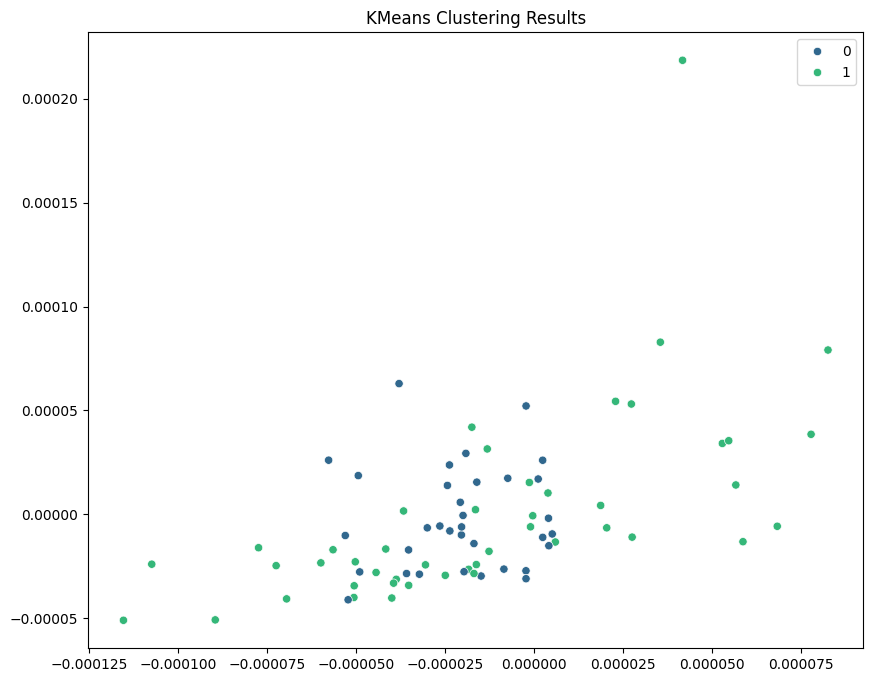

In [35]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Perform KMeans clustering
kmeans = KMeans(n_clusters=2, random_state=42)
cluster_labels = kmeans.fit_predict(X)

# Evaluate clustering performance using silhouette score
silhouette_avg = silhouette_score(X, cluster_labels)
print(f"Silhouette Score: {silhouette_avg:.2f}")

# Plot the clustering results
plt.figure(figsize=(10, 8))
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=cluster_labels, palette='viridis')
plt.title('KMeans Clustering Results')
plt.show()